College Football Transfer Portal
by Luke Chandler

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import seaborn as sns

file = 'CFB_Portal_Data.csv'
df = pd.read_csv(file)

Intro and Markdown

We are looking at the College Football Transfer Portal up until 2023. 

Entering the transfer portal is getting more and more popular every year. Players either want more money or more playing time.

The goal is to build a model that will predict what specific conference a player is likely to transfer to. We will look at what factors might influence this the most. 

Portal Data

In [2]:
df.head()

,Unnamed: 0,season,first_name,last_name,position,origin,destination,transfer_date,rating,stars,eligibility
0,0,2021,Cameron,Wilkins,LB,Missouri,UT San Antonio,2021-07-31T14:46:00.000Z,NaN,3.0,Immediate
1,1,2021,Stephon,Wright,DL,Arizona State,SMU,2021-07-29T15:50:00.000Z,NaN,4.0,Immediate
2,2,2021,Javar,Strong,S,Arkansas State,NaN,2021-07-28T15:25:00.000Z,NaN,3.0,Immediate
3,3,2021,Noah,Mitchell,LB,UT San Antonio,NaN,2021-07-27T15:22:00.000Z,NaN,3.0,Immediate
4,4,2021,Trivenskey,Mosley,RB,Southern Mississippi,NaN,2021-07-26T00:00:00.000Z,NaN,3.0,TBD


Here is a preview of the dataset we will be working with. 

Text(0, 0.5, 'Count')

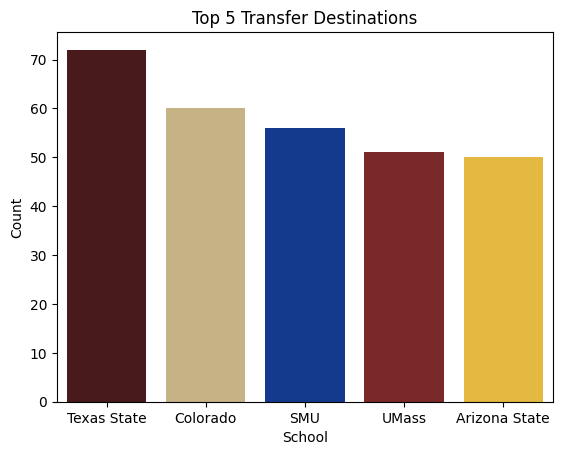

In [3]:
team_colors = {'Colorado' : '#CFB87C', 'Texas State' : '#501214', 'SMU' : '#0033A1', 'UMass' : '#881C1C', 'Arizona State' : '#FFC627'}
top5schools = df['destination'].value_counts().head(5).index
newdf = df[df['destination'].isin(top5schools)]
sns.countplot(data= newdf, x='destination', hue = 'destination', order=top5schools, palette=team_colors, legend=False)

plt.title('Top 5 Transfer Destinations')
plt.xlabel('School')
plt.ylabel('Count')

These are the top 5 schools with the most transfers received. Now, let's look at whether there are any trends in conferences. 

We create a dictionary for all the teams and their conferences. 

In [4]:
fbs_conferences = {
    # SEC
    'Alabama': 'SEC', 'Arkansas': 'SEC', 'Auburn': 'SEC', 'Florida': 'SEC', 
    'Georgia': 'SEC', 'Kentucky': 'SEC', 'LSU': 'SEC', 'Mississippi State': 'SEC', 
    'Missouri': 'SEC', 'Oklahoma': 'SEC', 'Ole Miss': 'SEC', 'South Carolina': 'SEC', 
    'Tennessee': 'SEC', 'Texas': 'SEC', 'Texas A&M': 'SEC', 'Vanderbilt': 'SEC',
    
    # Big Ten
    'Illinois': 'Big Ten', 'Indiana': 'Big Ten', 'Iowa': 'Big Ten', 'Maryland': 'Big Ten', 
    'Michigan': 'Big Ten', 'Michigan State': 'Big Ten', 'Minnesota': 'Big Ten', 'Nebraska': 'Big Ten', 
    'Northwestern': 'Big Ten', 'Ohio State': 'Big Ten', 'Oregon': 'Big Ten', 'Penn State': 'Big Ten', 
    'Purdue': 'Big Ten', 'Rutgers': 'Big Ten', 'UCLA': 'Big Ten', 'USC': 'Big Ten', 
    'Washington': 'Big Ten', 'Wisconsin': 'Big Ten',
    
    # Big 12
    'Arizona': 'Big 12', 'Arizona State': 'Big 12', 'Baylor': 'Big 12', 'BYU': 'Big 12', 
    'Cincinnati': 'Big 12', 'Colorado': 'Big 12', 'Houston': 'Big 12', 'Iowa State': 'Big 12', 
    'Kansas': 'Big 12', 'Kansas State': 'Big 12', 'Oklahoma State': 'Big 12', 'TCU': 'Big 12', 
    'Texas Tech': 'Big 12', 'UCF': 'Big 12', 'Utah': 'Big 12', 'West Virginia': 'Big 12',
    
    # ACC
    'Boston College': 'ACC', 'California': 'ACC', 'Clemson': 'ACC', 'Duke': 'ACC', 
    'Florida State': 'ACC', 'Georgia Tech': 'ACC', 'Louisville': 'ACC', 'Miami': 'ACC', 
    'NC State': 'ACC', 'North Carolina': 'ACC', 'Pitt': 'ACC', 'SMU': 'ACC', 
    'Stanford': 'ACC', 'Syracuse': 'ACC', 'Virginia': 'ACC', 'Virginia Tech': 'ACC', 'Wake Forest': 'ACC',
    
    # Sun Belt
    'Appalachian State': 'Sun Belt', 'Arkansas State': 'Sun Belt', 'Coastal Carolina': 'Sun Belt', 
    'Georgia Southern': 'Sun Belt', 'Georgia State': 'Sun Belt', 'James Madison': 'Sun Belt', 
    'Louisiana': 'Sun Belt', 'Marshall': 'Sun Belt', 'Old Dominion': 'Sun Belt', 'South Alabama': 'Sun Belt', 
    'Southern Miss': 'Sun Belt', 'Texas State': 'Sun Belt', 'Troy': 'Sun Belt', 'ULM': 'Sun Belt',

    # MAC
    'Akron': 'MAC', 'Ball State': 'MAC', 'Bowling Green': 'MAC', 'Buffalo': 'MAC', 
    'Central Michigan': 'MAC', 'Eastern Michigan': 'MAC', 'Kent State': 'MAC', 'Miami (OH)': 'MAC', 
    'Northern Illinois': 'MAC', 'Ohio': 'MAC', 'Toledo': 'MAC', 'UMass': 'MAC', 'Western Michigan': 'MAC',

    # American (AAC)
    'Army': 'AAC', 'Charlotte': 'AAC', 'East Carolina': 'AAC', 'Florida Atlantic': 'AAC', 
    'Memphis': 'AAC', 'Navy': 'AAC', 'North Texas': 'AAC', 'Rice': 'AAC', 'Temple': 'AAC', 
    'Tulane': 'AAC', 'Tulsa': 'AAC', 'UAB': 'AAC', 'USF': 'AAC', 'UTSA': 'AAC',

    # Mountain West
    'Air Force': 'Mountain West', 'Boise State': 'Mountain West', 'Colorado State': 'Mountain West', 
    'Fresno State': 'Mountain West', 'Hawaii': 'Mountain West', 'Nevada': 'Mountain West', 
    'New Mexico': 'Mountain West', 'San Diego State': 'Mountain West', 'San Jose State': 'Mountain West', 
    'UNLV': 'Mountain West', 'Utah State': 'Mountain West', 'Wyoming': 'Mountain West',

    # Conference USA
    'Delaware': 'CUSA', 'FIU': 'CUSA', 'Jacksonville State': 'CUSA', 'Kennesaw State': 'CUSA', 
    'Liberty': 'CUSA', 'Louisiana Tech': 'CUSA', 'Middle Tennessee': 'CUSA', 'Missouri State': 'CUSA', 
    'New Mexico State': 'CUSA', 'Sam Houston': 'CUSA', 'UTEP': 'CUSA', 'WKU': 'CUSA',

    # Pac-12 (Current Transition)
    'Oregon State': 'Pac-12', 'Washington State': 'Pac-12',

    # Independents
    'Notre Dame': 'Independent', 'UConn': 'Independent'
}

In [5]:
df['destinationconf'] = df['destination'].map(fbs_conferences)
conferenceord = df['destinationconf'].value_counts().index
df.head()

,Unnamed: 0,season,first_name,last_name,position,origin,destination,transfer_date,rating,stars,eligibility,destinationconf
0,0,2021,Cameron,Wilkins,LB,Missouri,UT San Antonio,2021-07-31T14:46:00.000Z,NaN,3.0,Immediate,NaN
1,1,2021,Stephon,Wright,DL,Arizona State,SMU,2021-07-29T15:50:00.000Z,NaN,4.0,Immediate,ACC
2,2,2021,Javar,Strong,S,Arkansas State,NaN,2021-07-28T15:25:00.000Z,NaN,3.0,Immediate,NaN
3,3,2021,Noah,Mitchell,LB,UT San Antonio,NaN,2021-07-27T15:22:00.000Z,NaN,3.0,Immediate,NaN
4,4,2021,Trivenskey,Mosley,RB,Southern Mississippi,NaN,2021-07-26T00:00:00.000Z,NaN,3.0,TBD,NaN


Text(0, 0.5, 'Conference')

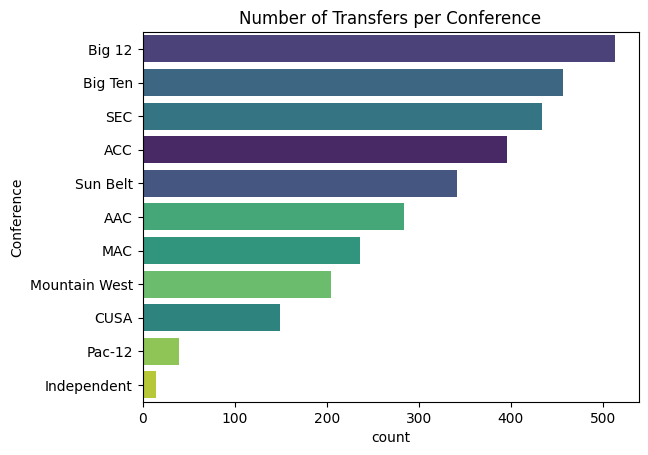

In [6]:
sns.countplot(data=df, y='destinationconf', hue='destinationconf', order=conferenceord, palette = 'viridis', legend=False)
plt.title('Number of Transfers per Conference')
plt.ylabel('Conference')

The Big 12 leads the way with the most transfer recruits. SEC is surprisingly sitting at 3rd, although it is arguably the best conference. 

Within those top 5 conferences, what positions have the highest count per conference?

Text(133.22222222222223, 0.5, 'Conference')

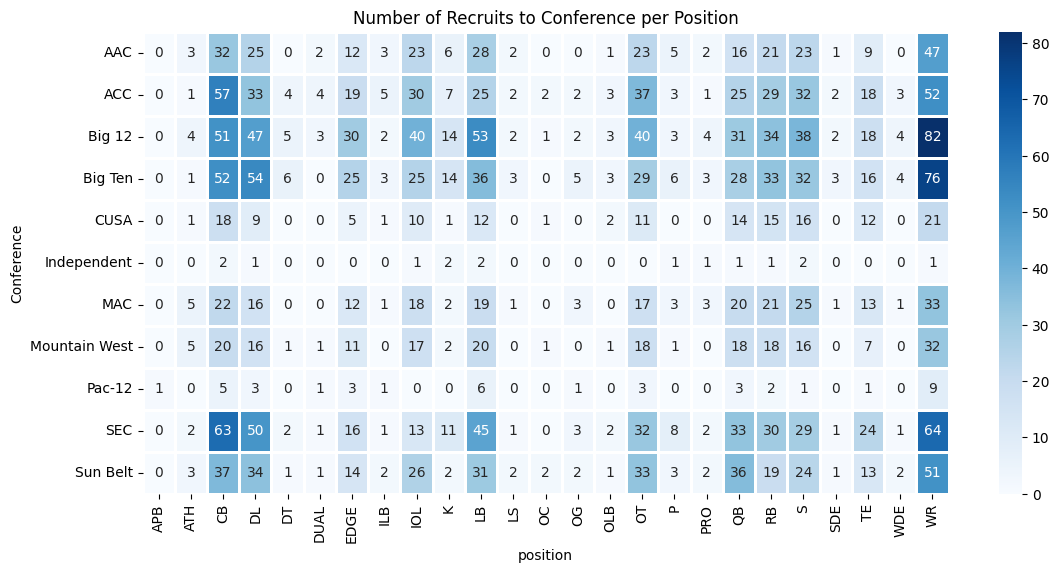

In [7]:
posdata = pd.crosstab(df['destinationconf'], df['position'])
plt.figure(figsize=(13,6))
sns.heatmap(posdata, annot=True, cmap='Blues', fmt='d', linewidths=1)

plt.title('Number of Recruits to Conference per Position')
plt.ylabel('Conference')

This heatmap provides valuable insight into which conferences receive the most transfers per position. The Big 12, and Big Ten get a lot of WR. The ACC and SEC get a lot of CB. 

In [8]:
pio.renderers.default = "notebook_connected"
confcolors = {'SEC': '#FFD046', 'Big Ten': '#0088CE', 'Big 12': '#EF483E', 'ACC': '#013CA6',       
    'Pac-12': '#004B91', 'Sun Belt': '#FFB612', 'MAC': '#171717', 'Mountain West': '#4A2677', 'AAC': '#002D62',       
    'CUSA': '#E31B23', 'Independent': '#808080'}
bubble = df.groupby('destinationconf').agg(total = ('destinationconf', 'count'), avgstars=('stars', 'mean')).reset_index()
bubble['avgstars'] = bubble['avgstars'].round(2)
fig = px.scatter(bubble, x='total', y='avgstars', size='avgstars', color='destinationconf', color_discrete_map = confcolors, opacity=1, hover_name = 'destinationconf', size_max=50, title = 'Avg Star Recruits per Conference')
fig.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b><br><br>" +
        "Total Incoming Transfers: %{x}<br>" +
        "Average Star Rating: %{y}<br>" +
        "<extra></extra>"
    )
)
fig.update_layout(yaxis_title='Star Rating', xaxis_title='Total')

From this scatterplot, we see the conferences with the highest-ranked recruits. This tells us that stars do correlate with which conference. Independent, SEC, and Big Ten lead the way.

Now it's time to build our model. RandomForest seems the most reasonable for the problem we're working with. 

In [9]:
df = df.dropna(subset=['destinationconf', 'stars', 'position', 'origin', 'rating'])


y=df['destinationconf']

features=['stars', 'position', 'origin', 'rating']
X=df[features]

Xenc = pd.get_dummies(X, columns=['position', 'origin'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(Xenc, y, test_size=0.2, random_state=42)

tmodel = RandomForestClassifier(n_estimators=100, random_state=42)
tmodel.fit(X_train, y_train)

ypred = tmodel.predict(X_test)

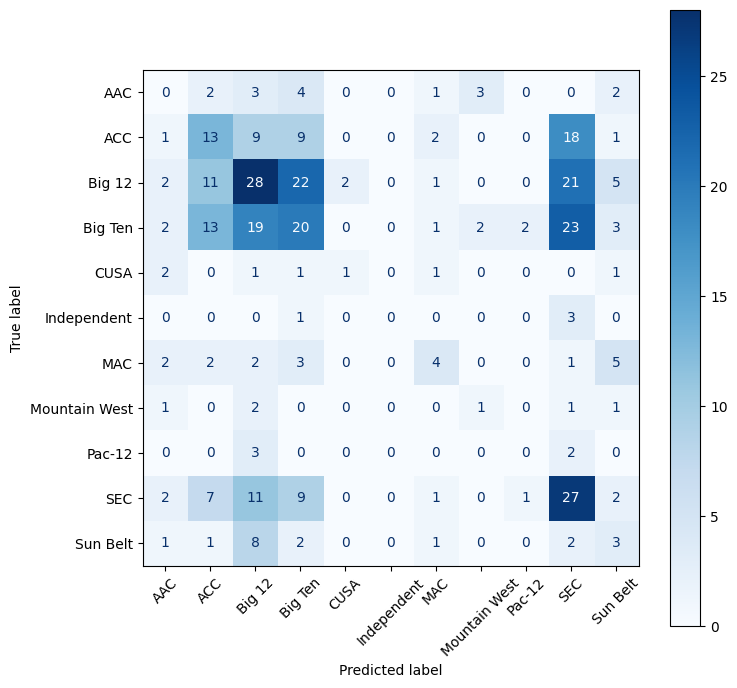

In [10]:
fig, ax = plt.subplots(figsize=(8,8))
cm = confusion_matrix(y_test, ypred, labels=tmodel.classes_)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tmodel.classes_)
cmd.plot(ax=ax, cmap='Blues', xticks_rotation=45)

We see quite a few False Positives for the bigger conferences, like the SEC, Big 10, Big 12.

In [11]:
print(classification_report(y_test, ypred, zero_division=0))

               precision    recall  f1-score   support

          AAC       0.00      0.00      0.00        15
          ACC       0.27      0.25      0.25        53
       Big 12       0.33      0.30      0.31        92
      Big Ten       0.28      0.24      0.26        85
         CUSA       0.33      0.14      0.20         7
  Independent       0.00      0.00      0.00         4
          MAC       0.33      0.21      0.26        19
Mountain West       0.17      0.17      0.17         6
       Pac-12       0.00      0.00      0.00         5
          SEC       0.28      0.45      0.34        60
     Sun Belt       0.13      0.17      0.15        18

     accuracy                           0.27       364
    macro avg       0.19      0.17      0.18       364
 weighted avg       0.27      0.27      0.26       364



The average f1-score of 0.27 shows this model needs some work. This dataset doesn't have NIL earnings or playing time data points, which may limit its accuracy. We are going to group some conferences to see if the accuracy jumps. 

In [12]:
p4conf = ['SEC', 'Big Ten', 'Big 12', 'ACC']

df['origintier'] = df['destinationconf'].apply(
    lambda x: 'PowerOrigin' if x in p4conf else 'G5_Origin')

features2 = ['stars', 'position', 'origintier', 'rating']

y2 = df['destinationconf']
X2 = df[features2]

Xenc2 = pd.get_dummies(X2, columns=['position', 'origintier'], drop_first=True)

X2_train, X2_test, y2_train, y2_test = train_test_split(Xenc2, y2, test_size = 0.2, random_state = 42)

t2model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight = 'balanced')
t2model.fit(X2_train, y2_train)

ypred2 = t2model.predict(X2_test)
print(classification_report(y2_test, ypred2, zero_division=0))

               precision    recall  f1-score   support

          AAC       0.15      0.13      0.14        15
          ACC       0.24      0.30      0.26        53
       Big 12       0.35      0.30      0.33        92
      Big Ten       0.28      0.22      0.25        85
         CUSA       0.17      0.14      0.15         7
  Independent       0.00      0.00      0.00         4
          MAC       0.42      0.42      0.42        19
Mountain West       0.27      0.50      0.35         6
       Pac-12       0.25      0.40      0.31         5
          SEC       0.31      0.38      0.34        60
     Sun Belt       0.35      0.33      0.34        18

     accuracy                           0.30       364
    macro avg       0.25      0.29      0.26       364
 weighted avg       0.30      0.30      0.29       364



Conclusion:

This dataset doesn't have enough data to predict which conference a player might transfer to accurately. The model f1-accuracy scores were:

-Raw Data: 0.16
-Null removal: 0.27
-Tiered Conferences: 0.30

Despite data cleaning and feature engineering, we weren't able to improve the f1 score by much. Deeper research found that the 'stars' column made a lot of noise and didn't allow the column to pick up on trends as easily. For better accuracy, data like NIL earnings and potential earnings, hometown, and starting opportunity would be needed. 